# EDA — Dataset EDOS (Sexism Detection)

### 1. Carga y estructura del dataset

In [2]:
import pandas as pd
df = pd.read_csv("https://raw.githubusercontent.com/rewire-online/edos/main/data/edos_labelled_aggregated.csv")
df.head()


,rewire_id,text,label_sexist,label_category,label_vector,split
0,sexism2022_english-9609,"In Nigeria, if you rape a woman, the men rape ...",not sexist,none,none,dev
1,sexism2022_english-16993,"Then, she's a keeper. 😉",not sexist,none,none,train
2,sexism2022_english-13149,This is like the Metallica video where the poo...,not sexist,none,none,train
3,sexism2022_english-13021,woman?,not sexist,none,none,train
4,sexism2022_english-966,I bet she wished she had a gun,not sexist,none,none,dev


### 2.Nulos 

In [3]:
df.isnull().sum()

rewire_id         0
text              0
label_sexist      0
label_category    0
label_vector      0
split             0
dtype: int64

### 3. Duplicados

In [4]:
df.duplicated().sum()

np.int64(0)

### 4. Análisis univariado — label_sexist

Contamos cuántos textos hay de cada clase (sexist / not sexist)
para ver la distribución general antes de cruzar con otras columnas.

In [5]:
df['label_sexist'].value_counts()

label_sexist
not sexist    15146
sexist         4854
Name: count, dtype: int64

#### Visualización — distribución de label_sexist

Gráfico de torta para mostrar la proporción de cada clase.
Se confirma el desbalance: ~76% not sexist vs ~24% sexist.

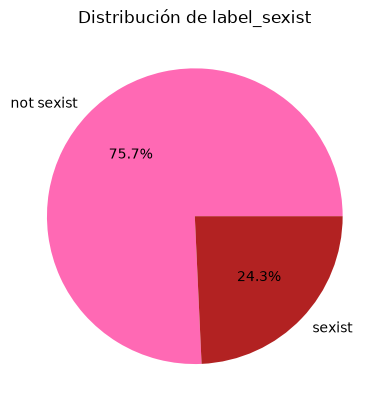

In [6]:
import matplotlib.pyplot as plt

conteo = df['label_sexist'].value_counts()

plt.pie(conteo, labels=conteo.index, autopct='%1.1f%%', colors=['#FF69B4', '#B22222'])
plt.title('Distribución de label_sexist')
plt.show()

### 5. Análisis univariado — label_category (solo textos sexistas)

Esta columna solo tiene valor real cuando `label_sexist = "sexist"`.
En el resto de las filas aparece como "none", así que filtramos
primero para no diluir el análisis con ese valor dominante.

In [7]:
sexistas = df[df['label_sexist'] == 'sexist']
sexistas['label_category'].value_counts()

label_category
2. derogation                               2271
3. animosity                                1665
4. prejudiced discussions                    475
1. threats, plans to harm and incitement     443
Name: count, dtype: int64

### Visualización — distribución de label_category (solo sexistas)

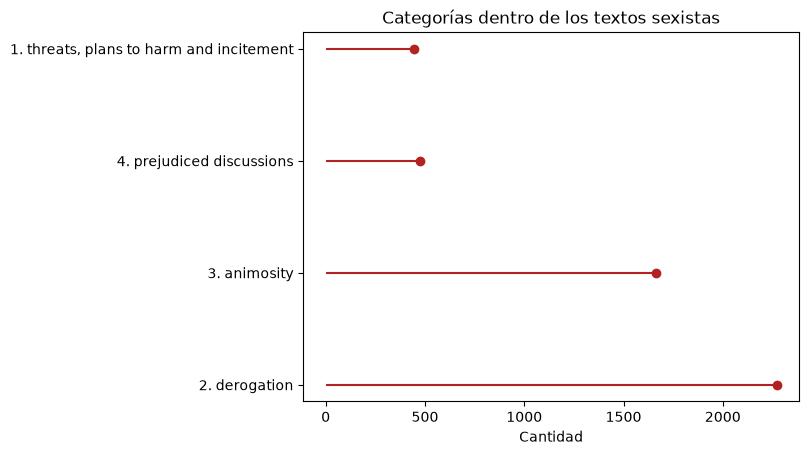

In [9]:
import matplotlib.pyplot as plt

conteo_cat = sexistas['label_category'].value_counts()

plt.hlines(y=conteo_cat.index, xmin=0, xmax=conteo_cat.values, color='#B22222')
plt.plot(conteo_cat.values, conteo_cat.index, "o", color='#B22222')
plt.title('Categorías dentro de los textos sexistas')
plt.xlabel('Cantidad')
plt.show()